In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# 1. Configuration for reproducibility
torch.manual_seed(42)

# 2. Define the Linear Regression Model
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(LinearRegressionModel, self).__init__()
        # Linear layer performs: y = xA^T + b
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

In [3]:
# 3. Data Preparation (Mock Data)
# Target function: y = 2x + 1
X = torch.randn(100, 1)
y = 2 * X + 1 + 0.1 * torch.randn(100, 1)  # Added small noise

In [4]:
# 4. Initialization
model = LinearRegressionModel(input_dim=1, output_dim=1)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [5]:
# 5. Training Loop
epochs = 100

# Tracking metrics
loss_history = []

for epoch in range(epochs):
    # Forward pass
    predictions = model(X)
    loss = loss_fn(predictions, y)

    # Backward pass and optimization
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update weights

    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [20/100], Loss: 1.0865
Epoch [40/100], Loss: 0.4968
Epoch [60/100], Loss: 0.2301
Epoch [80/100], Loss: 0.1091
Epoch [100/100], Loss: 0.0541


In [6]:
# 6. Inference
model.eval()
with torch.no_grad():
    sample = torch.tensor([[10.0]])
    prediction = model(sample)
    print(f"\nPrediction for x=10.0: {prediction.item():.4f} (Target is ~21.0)")



Prediction for x=10.0: 18.8721 (Target is ~21.0)


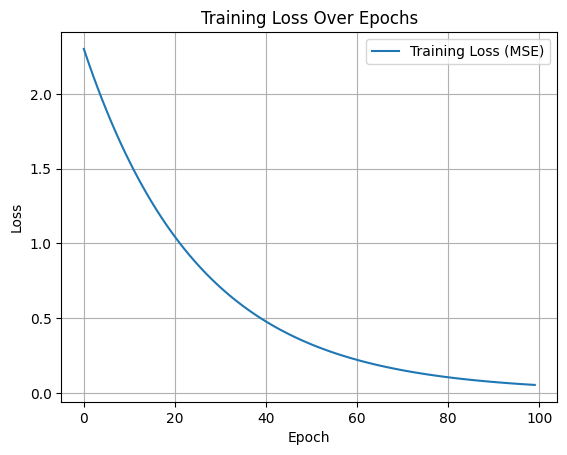

In [7]:
# plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss (MSE)')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)